In [ ]:
import numpy as np
import random

alpha = 0.1    # Learning rate
gamma = 0.9    # Discount factor
epsilon = 0.2  # Exploration rate 
episodes = 100

# Environment: 5 states (0, 1, 2, 3, 4)
# Actions: 0 = Left, 1 = Right
n_states = 5
n_actions = 2
goal_state = 4

# Initialize Q-Table with zeros
q_table = np.zeros((n_states, n_actions))

print("Initial Q-Table:")
print(q_table)

Initial Q-Table:
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [ ]:
for i in range(episodes):
    state = 0  # Start at the beginning
    
    while state != goal_state:
        # 1. Choose Action (Epsilon-Greedy Strategy)
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, 1) # Explore: random action
        else:
            action = np.argmax(q_table[state]) # Exploit: best known action
            
        # 2. "Move" in the environment
        if action == 1: # Move Right
            next_state = min(state + 1, n_states - 1)
        else: # Move Left
            next_state = max(state - 1, 0)
            
        # 3. Get Reward
        reward = 10 if next_state == goal_state else 0
        
        # 4. Update Q-Table (The Bellman Equation)
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        
        # Update rule
        q_table[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)
        
        state = next_state

print("\nTrained Q-Table (Row=State, Col=Action [L, R]):")
print(np.round(q_table, 2))


Trained Q-Table (Row=State, Col=Action [L, R]):
[[ 3.23  7.26]
 [ 4.57  8.09]
 [ 2.01  9.  ]
 [ 5.78 10.  ]
 [ 0.    0.  ]]


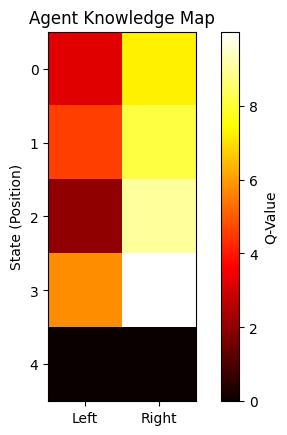

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(q_table, cmap='hot', interpolation='nearest')
plt.colorbar(label='Q-Value')
plt.xticks([0, 1], ['Left', 'Right'])
plt.ylabel('State (Position)')
plt.title('Agent Knowledge Map')
plt.show()